# SHAP analysis: what the day-30 risk model learned

BAN6800 Module 4, Desmond Amos Bature. Explains the registered XGBoost model (`models/model.joblib`) on the grouped hold-out test set.

* **Global**: which features move risk most across all learners (mean absolute SHAP value), and in which direction (beeswarm).
* **Dependence**: how the strongest feature changes risk across its range.
* **Local**: why one specific learner was flagged (waterfall), cross-checked with LIME.
* **Counterfactual**: the smallest change in behaviour that would have taken that learner below the flag threshold (DiCE).

SHAP values are in log-odds of non-completion (Lundberg and Lee, 2017).

In [1]:
import json, warnings
from pathlib import Path
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
warnings.filterwarnings("ignore")
import os, sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.models import data, explain
%matplotlib inline

model = joblib.load(ROOT / "models" / "model.joblib")
meta = json.loads((ROOT / "models" / "model_metadata.json").read_text())
df = data.load(ROOT / "data" / "processed")
split = data.grouped_holdout(df, seed=42)
p = model.predict_proba(split.X_test)[:, 1]
thr = meta["threshold"]
print(meta["algorithm"], "| registry", meta["registry"], "| threshold", round(thr, 3))
print("test learners:", len(split.y_test), "| flagged:", int((p >= thr).sum()))

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xgboost | registry {'name': 'learner-risk-noncompletion', 'version': 1, 'alias': 'champion', 'stage': 'Staging'} | threshold 0.593
test learners: 5455 | flagged: 1360


## 1. Global importance

In [2]:
sv, Xt = explain.shap_values(model, split.X_test)
imp = explain.global_importance(sv)
imp.head(12)[["label", "mean_abs_shap"]].round(3)

,label,mean_abs_shap
0,"Mean score, assessments by day 30",0.382
1,Share of early assessments submitted,0.250
2,"Active days, days 0 to 29",0.213
3,"Clicks, week 4",0.147
4,Module BBB,0.134
5,Module FFF,0.132
6,VLE clicks before start,0.123
7,Previous attempts,0.077
8,"Clicks, week 2",0.076
9,Credits studied,0.063


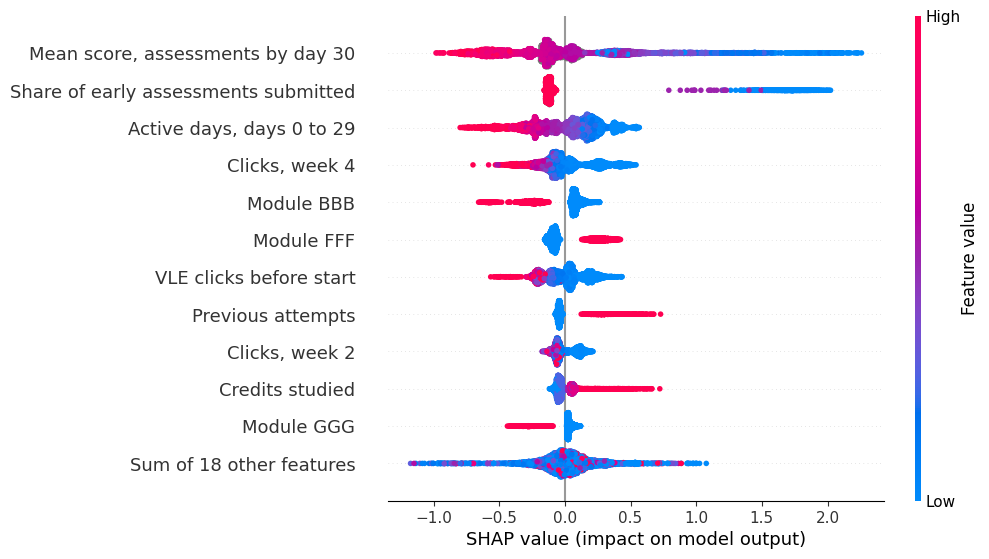

In [3]:
shap.plots.beeswarm(shap.Explanation(values=sv.values, base_values=sv.base_values, data=sv.data,
                                     feature_names=[explain.readable(f) for f in sv.feature_names]),
                    max_display=12)

**Reading it.** Early assessment behaviour dominates. A low mean score on early assessments pushes risk up, and so does submitting fewer of the assessments that were due; submitting all of them pulls risk down. Activity comes next: few active days and a quiet week 4 raise risk. Module matters (FFF raises it; AAA, BBB and GGG lower it), and a previous attempt at the module raises it. None of the protected attributes is an input.

## 2. Dependence on the strongest feature

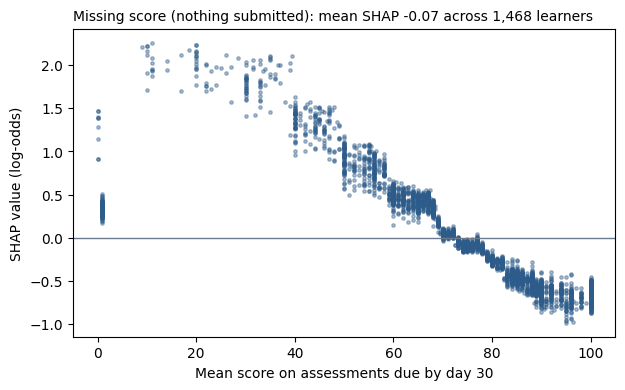

In [4]:
j = list(sv.feature_names).index("mean_score_by_30")
x = sv.data[:, j]; v = sv.values[:, j]
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x[~np.isnan(x)], v[~np.isnan(x)], s=6, alpha=0.4, color="#2E5C8A", label="scored learners")
ax.axhline(0, color="#6B7A8C", lw=1)
ax.set_xlabel("Mean score on assessments due by day 30"); ax.set_ylabel("SHAP value (log-odds)")
miss = v[np.isnan(x)]
ax.set_title(f"Missing score (nothing submitted): mean SHAP {miss.mean():+.2f} across {len(miss):,} learners", loc="left", fontsize=10)
plt.show()

Risk falls steadily as the early score rises: on average about +1.2 log-odds below a score of 50, +0.8 between 50 and 60, close to zero between 70 and 80, and about -0.65 above 90. A missing score on its own is roughly neutral (mean -0.07), because most missing scores (1,035 of 1,468 in the test set) belong to modules with nothing due by day 30. When an assessment was due and nothing was submitted, the warning is carried by the submission-share feature instead (about +1.7 log-odds when the share is zero), which is why the two features rank first and second.

## 3. Local explanation: one flagged learner

In [5]:
# Same selection rule as src/models/run_all.py: a correctly flagged non-completer with an
# assessment due and some VLE activity, from the upper quartile of risk, for whom DiCE finds a
# feasible counterfactual (see explain.pick_learner_a and explain.feasible).
import contextlib, io
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):  # DiCE progress bars
    a, cf, tries = explain.pick_learner_a(model, split.X_train, split.y_train, split.X_test, split.y_test, p, thr)
print(f"Learner A: risk {p[a]:.2f} (threshold {thr:.2f}), outcome = {'did not complete' if split.y_test[a] else 'completed'}, candidates tried = {tries}")
split.X_test.iloc[a].to_frame("value")

Learner A: risk 0.90 (threshold 0.59), outcome = did not complete, candidates tried = 4


,value
code_module,FFF
num_of_prev_attempts,0.0
studied_credits,120.0
date_registration,-22.0
date_registration_missing,0.0
n_due_by_30,1.0
n_submitted_by_30,0.0
n_banked_by_30,0.0
submit_rate_by_30,0.0
mean_score_by_30,NaN


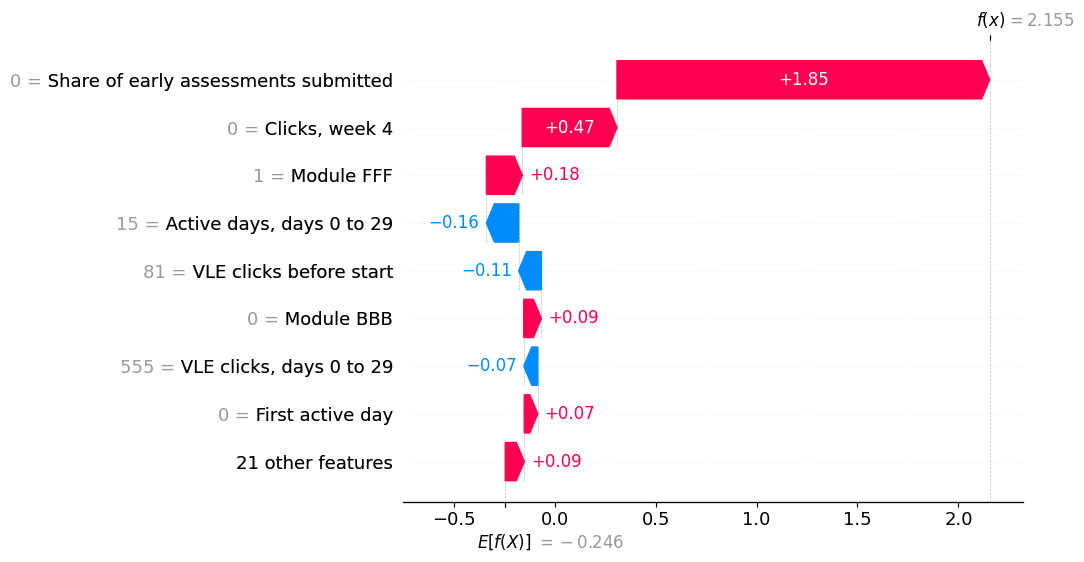

In [6]:
one = shap.Explanation(values=sv.values[a], base_values=sv.base_values[a], data=sv.data[a],
                       feature_names=[explain.readable(f) for f in sv.feature_names])
shap.plots.waterfall(one, max_display=9)

In [7]:
pd.DataFrame(explain.lime_explanation(model, split.X_train, split.X_test.iloc[[a]]))

,rule,weight
0,"Mean score, assessments by day 30 is missing",0.096013
1,"Clicks, week 4 <= 5.00",0.090912
2,code_module=FFF,0.067784
3,Credits studied > 90.00,0.027476
4,"10.00 < Active days, days 0 to 29 <= 17.00",-0.022036
5,First active day <= 0.00,0.021958


SHAP and LIME agree on the story for Learner A, a learner on module FFF. One assessment was due by day 30 and was not submitted, and activity faded week by week (432 clicks in week 1, 67 in week 2, 56 in week 3) before stopping altogether in week 4. Not submitting is the largest push towards risk, followed by the silent week 4. Fifteen active days and some activity before the start pull risk down slightly. LIME, a separate method, picks out the same signals: no early score, no clicks in week 4, and the module. Two independent methods reaching the same reasons is the evidence that the explanation reflects the model, not an artefact of one method (Ribeiro et al., 2016).

## 4. Counterfactual: what would have changed the flag

In [8]:
cols = ["n_submitted_by_30", "clicks_0_29", "clicks_wk3", "clicks_wk4", "active_days_0_29", "distinct_sites_0_29", "risk_score", "below_threshold"]
pd.concat([split.X_test.iloc[[a]].assign(risk_score=p[a], below_threshold=False)[cols], cf[cols]], keys=["actual", "counterfactual"])

n_submitted_by_30  clicks_0_29  clicks_wk3  clicks_wk4  \
actual         4849                0.0        555.0        56.0         0.0   
counterfactual 0                   0.0        730.0        56.0       175.0   
               1                   0.0        815.0        56.0       260.0   
               2                   0.0        812.0        56.0       257.0   

                     active_days_0_29  distinct_sites_0_29  risk_score  \
actual         4849              15.0                 46.0    0.896128   
counterfactual 0                 24.0                 46.0    0.574923   
               1                 15.0                 46.0    0.596944   
               2                 15.0                 46.0    0.596944   

                     below_threshold  
actual         4849            False  
counterfactual 0                True  
               1               False  
               2               False

Only behaviours a coach could influence were allowed to change (Mothilal et al., 2020), and every proposal was checked for feasibility: weeks 1 and 2 are history, and new active days can only come from new clicks in weeks 3 and 4 (`explain.feasible`). The change DiCE found for Learner A is staying active through week 4: about 175 clicks spread over nine more days (24 active days in the month) would have taken the risk from 0.90 to 0.57, below the 0.59 threshold. That is the coaching conversation. A check-in at the start of week 4, when this learner's activity had already been falling for two weeks, would have come before the outcome was decided.